# Testing 

**Hyperparameter setup**

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from random import randint

# =============================================================================
# HYPERPARAMETERS - TWEAK THESE
# =============================================================================

# Network
N_INPUTS = 4            # Goal direction inputs
N_OUTPUTS = 4           # Actions: up, down, left, right
THRESHOLD = 1.0         # Spike threshold
BETA = 0.8              # Membrane decay
N_TIMESTEPS = 25        # Simulation steps per forward pass

# Weights
W_INIT_DIAG = 0.05       # Initial diagonal (correct) weights
W_INIT_OFF = 0.05       # Initial off-diagonal weights
W_MIN = 0.01            # Minimum weight
W_MAX = 1.5             # Maximum weight

# Learning
LR_POS = 0.1           # Learning rate for positive rewards
LR_NEG = 0.05           # Learning rate for negative rewards
LR_COMPETE = 0.05       # Competition: weaken other actions on success

# Training
N_EPISODES = 500      # Number of training episodes
MAX_STEPS = 50         # Max steps per episode
EPSILON_START = 0.5     # Initial exploration
EPSILON_END = 0.1       # Final exploration

print("Hyperparameters loaded ✓")
print(f"  Network: {N_INPUTS}→{N_OUTPUTS}, threshold={THRESHOLD}, beta={BETA}")
print(f"  Learning: lr+={LR_POS}, lr-={LR_NEG}, compete={LR_COMPETE}")
print(f"  Training: {N_EPISODES} episodes, ε: {EPSILON_START}→{EPSILON_END}")

Hyperparameters loaded ✓
  Network: 4→4, threshold=1.0, beta=0.8
  Learning: lr+=0.1, lr-=0.05, compete=0.05
  Training: 500 episodes, ε: 0.5→0.1


In [16]:
class GridEnv:
    """
    Grid-based navigation environment for SNN training.
    
    Grid encoding:
    - 0: free space
    - 1: obstacle/wall
    - 3: goal position
    """
    def __init__(self, grid, start_pos=None):
        """
        Args:
            grid: 2D numpy array (15x15) with 0=free, 1=wall, 3=goal
            start_pos: (row, col) tuple for start position. If None, uses center (7, 7)
        """
        self.grid = grid.copy()
        self.height, self.width = grid.shape
        
        # Set start position
        if start_pos is not None:
            self.start = start_pos
        else:
            # Default to center
            self.start = (self.height // 2, self.width // 2)
        
        # Find goal position (marked with 3)
        goal_positions = np.argwhere(grid == 3)
        if len(goal_positions) > 0:
            self.goal = tuple(goal_positions[0])
        else:
            self.goal = (1, 1)  # Fallback
        
        # Current position
        self.pos = self.start
        
        # Action mapping: 0=up, 1=down, 2=left, 3=right
        self.action_map = {
            0: (-1, 0),   # Up
            1: (1, 0),    # Down
            2: (0, -1),   # Left
            3: (0, 1)     # Right
        }
    
    def reset(self):
        """Reset to start position and return observation."""
        self.pos = self.start
        return self._get_observation()
    
    def _get_observation(self):
        """
        Get direction to goal as 4-element vector [up, down, left, right].
        Values are normalized distances (0-1 range).
        """
        dy = self.goal[0] - self.pos[0]  # Positive = goal is down
        dx = self.goal[1] - self.pos[1]  # Positive = goal is right
        
        # Normalize by grid size
        max_dist = max(self.height, self.width)
        
        obs = torch.zeros(4)
        obs[0] = max(0, -dy) / max_dist  # Up (negative dy)
        obs[1] = max(0, dy) / max_dist   # Down (positive dy)
        obs[2] = max(0, -dx) / max_dist  # Left (negative dx)
        obs[3] = max(0, dx) / max_dist   # Right (positive dx)
        
        return obs
    
    def is_valid(self, pos):
        """Check if position is valid (in bounds and not obstacle)."""
        i, j = pos
        if not (0 <= i < self.height and 0 <= j < self.width):
            return False
        return self.grid[i, j] != 1  # Not a wall
    
    def step(self, action):
        """
        Take action and return (observation, reward, done).
        
        Args:
            action: 0=up, 1=down, 2=left, 3=right
            
        Returns:
            obs: torch tensor with direction to goal
            reward: float reward
            done: bool, True if goal reached
        """
        # Calculate new position
        di, dj = self.action_map[action]
        new_pos = (self.pos[0] + di, self.pos[1] + dj)
        
        # Check if move is valid
        if self.is_valid(new_pos):
            old_dist = self._distance_to_goal(self.pos)
            self.pos = new_pos
            new_dist = self._distance_to_goal(self.pos)
            
            # Check if goal reached
            if self.pos == self.goal:
                return self._get_observation(), 10.0, True
            
            # Reward for moving closer to goal
            if new_dist < old_dist:
                reward = 0.1
            else:
                reward = -0.05  # Small penalty for moving away
                
            return self._get_observation(), reward, False
        else:
            # Hit wall - stay in place with penalty
            return self._get_observation(), -1.0, False
    
    def _distance_to_goal(self, pos):
        """Manhattan distance to goal."""
        return abs(pos[0] - self.goal[0]) + abs(pos[1] - self.goal[1])
    
    def get_state(self):
        """Return current position."""
        return self.pos

print("GridEnv updated with start_pos parameter ✓")

GridEnv updated with start_pos parameter ✓


**Function setup**

In [17]:
class NavigationSNN:
    def __init__(self):
        self.w = torch.eye(N_OUTPUTS) * W_INIT_DIAG + W_INIT_OFF
        self.threshold = THRESHOLD
        self.beta = BETA
        self.last_mem = None
        self.last_input = None
    
    def forward(self, obs):
        x = obs[:N_INPUTS]
        self.last_input = x
        
        mem = torch.zeros(N_OUTPUTS)
        spikes = torch.zeros(N_OUTPUTS)
        
        for t in range(N_TIMESTEPS):
            spk_in = x if t < 3 else (torch.rand(N_INPUTS) < x).float()
            cur = self.w @ spk_in
            mem = self.beta * mem + cur
            spk_out = (mem >= self.threshold).float()
            mem = mem * (1 - spk_out)
            spikes += spk_out
        
        self.last_mem = mem
        return spikes
    
    def learn(self, action, reward):
        if reward > 0:
            self.w[action] += LR_POS * reward * self.last_input
            for i in range(N_OUTPUTS):
                if i != action:
                    self.w[i] -= LR_COMPETE * reward * self.last_input
        else:
            self.w[action] += LR_NEG * reward * self.last_input
        
        self.w = torch.clamp(self.w, W_MIN, W_MAX)
    
    def get_action(self, spikes):
        if spikes.sum() > 0:
            noisy = spikes + torch.rand(N_OUTPUTS) * 0.01
            return noisy.argmax().item()
        return self.last_mem.argmax().item()

print("NavigationSNN defined ✓")

NavigationSNN defined ✓


**Grid Creation**

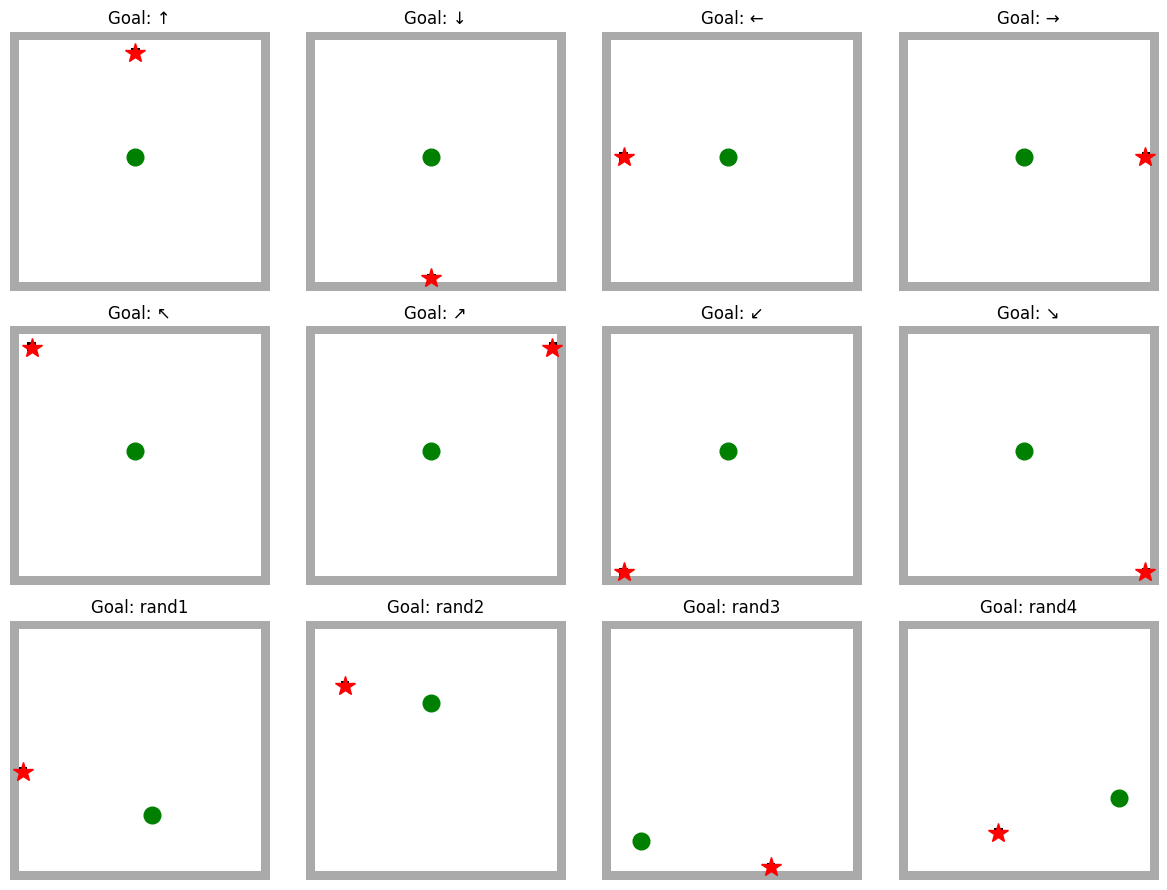

Created 12 grids ✓


In [18]:
def make_grid(goal_pos, start_pos=None):
    """
    Create a 15x15 grid with walls on borders.
    
    Args:
        goal_pos: (row, col) position for goal
        start_pos: (row, col) position for start. If None, uses center (14, 14)
    
    Returns:
        grid: 30x30 numpy array
        start_pos: (row, col) tuple for start position
    """
    grid = np.zeros((30, 30), dtype=np.uint8)
    grid[0, :] = grid[-1, :] = grid[:, 0] = grid[:, -1] = 1
    grid[goal_pos] = 3
    
    if start_pos is None:
        start_pos = (14, 14)  # Default to center
    
    return grid, start_pos

# Create grids with custom start positions
grids = [
    make_grid((2, 14)),                # Up (center start)
    make_grid((28, 14)),               # Down (center start)
    make_grid((14, 2)),                # Left (center start)
    make_grid((14, 28)),               # Right (center start)
    make_grid((2, 2)),                # Up-Left (center start)
    make_grid((2, 28)),               # Up-Right (center start)
    make_grid((28, 2)),               # Down-Left (center start)
    make_grid((28, 28)),              # Down-Right (center start)
    make_grid((randint(1, 28), randint(1, 28)), start_pos=((randint(1, 28), randint(1, 28)))),  # Random goal
    make_grid((randint(1, 28), randint(1, 28)), start_pos=((randint(1, 28), randint(1, 28)))),  # Random goal
    make_grid((randint(1, 28), randint(1, 28)), start_pos=((randint(1, 28), randint(1, 28)))),  # Random goal
    make_grid((randint(1, 28), randint(1, 28)), start_pos=((randint(1, 28), randint(1, 28)))),  # Random goal
]

# Visualize
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
labels = ['↑', '↓', '←', '→', '↖', '↗', '↙', '↘', 'rand1', 'rand2', 'rand3', 'rand4']

for i, (ax, (grid, start)) in enumerate(zip(axes.flat, grids)):
    ax.imshow(grid, cmap='gray_r')
    ax.plot(start[1], start[0], 'go', markersize=12, label='Start')
    
    # Find goal position
    goal_pos = np.argwhere(grid == 3)[0]
    ax.plot(goal_pos[1], goal_pos[0], 'r*', markersize=15, label='Goal')
    
    ax.set_title(f'Goal: {labels[i]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Created {len(grids)} grids ✓")

**Training**

In [19]:
# =============================================================================
# CREATE NETWORK INSTANCE
# =============================================================================

net = NavigationSNN()
print("Network created ✓")
print("Initial weights:")
print(net.w.numpy().round(2))

# Initialize tracking lists
rewards = []
successes = []

Network created ✓
Initial weights:
[[0.1  0.05 0.05 0.05]
 [0.05 0.1  0.05 0.05]
 [0.05 0.05 0.1  0.05]
 [0.05 0.05 0.05 0.1 ]]


In [20]:
# =============================================================================
# TRAINING LOOP
# =============================================================================

for ep in range(N_EPISODES):
    epsilon = 0.5 - 0.4 * (ep / N_EPISODES)
    
    grid, start = grids[np.random.randint(4)]  # Unpack tuple
    env = GridEnv(grid, start_pos=start)       # Pass start position
    obs = env.reset()
    total_reward, done = 0, False
    
    for _ in range(MAX_STEPS):
        spikes = net.forward(obs)
        action = np.random.randint(4) if np.random.random() < epsilon else net.get_action(spikes)
        obs, reward, done = env.step(action)
        total_reward += reward
        net.learn(action, reward)
        if done:
            break
    
    rewards.append(total_reward)
    successes.append(float(done))
    
    if (ep + 1) % 50 == 0:
        print(f"Ep {ep+1}: Reward={np.mean(rewards[-100:]):.1f}, Success={np.mean(successes[-100:]):.0%}")

print("\n✓ Training complete!")
print("\nFinal weights:")
print(net.w.numpy().round(2))

Ep 50: Reward=11.3, Success=98%
Ep 100: Reward=11.4, Success=99%
Ep 150: Reward=11.4, Success=100%
Ep 200: Reward=11.4, Success=100%
Ep 250: Reward=11.4, Success=100%
Ep 300: Reward=11.4, Success=100%
Ep 350: Reward=11.3, Success=100%
Ep 400: Reward=11.3, Success=100%
Ep 450: Reward=11.3, Success=100%
Ep 500: Reward=11.3, Success=100%

✓ Training complete!

Final weights:
[[1.5  0.01 0.01 0.01]
 [0.01 1.5  0.01 0.01]
 [0.01 0.01 1.5  0.01]
 [0.01 0.01 0.01 1.5 ]]


**Plotting results**

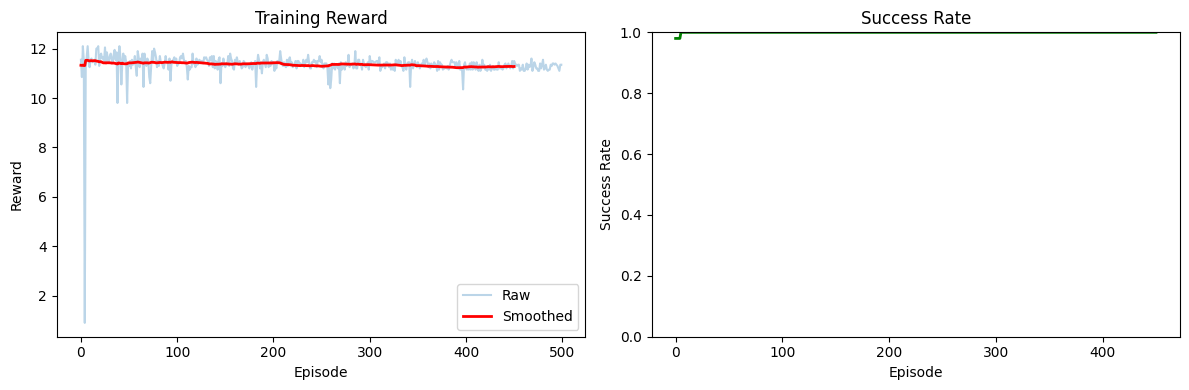

In [21]:
# =============================================================================
# CELL 5: Plot Results
# =============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(rewards, alpha=0.3, label='Raw')
if len(rewards) > 50:
    ax1.plot(np.convolve(rewards, np.ones(50)/50, mode='valid'), 'r-', lw=2, label='Smoothed')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Reward')
ax1.set_title('Training Reward')
ax1.legend()

if len(successes) > 50:
    ax2.plot(np.convolve(successes, np.ones(50)/50, mode='valid'), 'g-', lw=2)
ax2.set_xlabel('Episode')
ax2.set_ylabel('Success Rate')
ax2.set_title('Success Rate')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [22]:
# Testing code (Cell 6)
grid, start = grids[7]  # Unpack
env = GridEnv(grid, start_pos=start)
obs = env.reset()
path = [tuple(env.pos)]

print(f"Start: {env.start}, Goal: {env.goal}\n")

for step in range(50):
    spikes = net.forward(obs)
    action = net.get_action(spikes)
    obs, reward, done = env.step(action)
    path.append(tuple(env.pos))
    
    arrow = ['↑', '↓', '←', '→'][action]
    print(f"Step {step:2d}: {arrow}  spikes={spikes.int().tolist()}  pos={env.pos}")
    
    if done:
        print(f"\n🎯 GOAL REACHED in {step+1} steps!")
        break
else:
    print(f"\n❌ Did not reach goal in 30 steps")

Start: (14, 14), Goal: (np.int64(28), np.int64(28))

Step  0: ↓  spikes=[0, 14, 0, 12]  pos=(15, 14)
Step  1: ↓  spikes=[0, 10, 0, 9]  pos=(16, 14)
Step  2: →  spikes=[0, 9, 0, 14]  pos=(16, 15)
Step  3: ↓  spikes=[0, 11, 0, 9]  pos=(17, 15)
Step  4: ↓  spikes=[0, 10, 0, 9]  pos=(18, 15)
Step  5: ↓  spikes=[0, 11, 0, 7]  pos=(19, 15)
Step  6: →  spikes=[0, 7, 0, 12]  pos=(19, 16)
Step  7: →  spikes=[0, 8, 0, 9]  pos=(19, 17)
Step  8: ↓  spikes=[0, 8, 0, 8]  pos=(20, 17)
Step  9: →  spikes=[0, 5, 0, 14]  pos=(20, 18)
Step 10: →  spikes=[0, 8, 0, 9]  pos=(20, 19)
Step 11: →  spikes=[0, 6, 0, 8]  pos=(20, 20)
Step 12: →  spikes=[0, 5, 0, 9]  pos=(20, 21)
Step 13: ↓  spikes=[0, 4, 0, 2]  pos=(21, 21)
Step 14: →  spikes=[0, 3, 0, 3]  pos=(21, 22)
Step 15: ↓  spikes=[0, 7, 0, 5]  pos=(22, 22)
Step 16: ↓  spikes=[0, 6, 0, 4]  pos=(23, 22)
Step 17: ↓  spikes=[0, 5, 0, 5]  pos=(24, 22)
Step 18: ↓  spikes=[0, 3, 0, 2]  pos=(25, 22)
Step 19: →  spikes=[0, 1, 0, 4]  pos=(25, 23)
Step 20: →  spikes

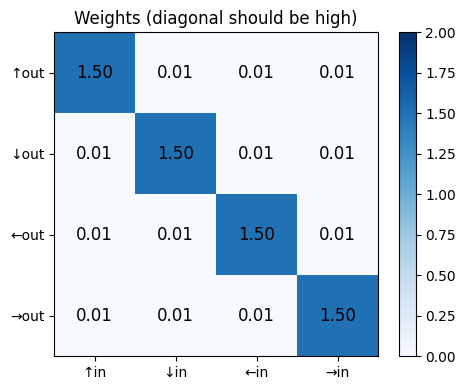

In [23]:
# =============================================================================
# CELL 7: Visualize Weights
# =============================================================================

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(net.w.numpy(), cmap='Blues', vmin=0, vmax=2)
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['↑in', '↓in', '←in', '→in'])
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(['↑out', '↓out', '←out', '→out'])
ax.set_title('Weights (diagonal should be high)')
plt.colorbar(im)

for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{net.w[i,j]:.2f}', ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

In [24]:
# =============================================================================
# CELL 8: Diagnostics
# =============================================================================

print("=== Network Diagnostics ===\n")

grid, start = grids[0]  # Unpack the tuple
env = GridEnv(grid, start_pos=start)
obs = env.reset()

print(f"Input obs: {obs.numpy().round(2)}")
print(f"  [up, down, left, right]\n")

spikes = net.forward(obs)
print(f"Output spikes: {spikes.int().tolist()}")
print(f"Output membrane: {net.last_mem.numpy().round(3)}")
print(f"Selected action: {['↑', '↓', '←', '→'][net.get_action(spikes)]}\n")

print("Weights:")
print("        ↑in    ↓in    ←in    →in")
for i, label in enumerate(['↑out', '↓out', '←out', '→out']):
    print(f"{label}  {net.w[i].numpy().round(3)}")

=== Network Diagnostics ===

Input obs: [0.4 0.  0.  0. ]
  [up, down, left, right]

Output spikes: [12, 0, 0, 0]
Output membrane: [0.   0.02 0.02 0.02]
Selected action: ↑

Weights:
        ↑in    ↓in    ←in    →in
↑out  [1.5  0.01 0.01 0.01]
↓out  [0.01  1.5   0.011 0.01 ]
←out  [0.01 0.01 1.5  0.01]
→out  [0.01 0.01 0.01 1.5 ]


**Visualize Paths**

In [25]:
# =============================================================================
# ALL VISUALIZATION FUNCTIONS (COMPLETE AND CORRECTED)
# =============================================================================

def visualize_all_grids(net, grids, max_steps=30):
    n_grids = len(grids)
    cols = 4
    rows = (n_grids + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    axes = axes.flatten() if n_grids > 1 else [axes]
    
    for i, (ax, (grid, start)) in enumerate(zip(axes, grids)):
        env = GridEnv(grid, start_pos=start)
        obs = env.reset()
        path = [env.pos]
        
        done = False
        for step in range(max_steps):
            spikes = net.forward(obs)
            action = net.get_action(spikes)
            obs, reward, done = env.step(action)
            path.append(env.pos)
            if done:
                break
        
        ax.imshow(grid, cmap='gray_r', alpha=0.6)
        
        if len(path) > 1:
            path_array = np.array(path)
            ax.plot(path_array[:, 1], path_array[:, 0], 'b-', linewidth=2, alpha=0.7)
            ax.plot(path_array[:, 1], path_array[:, 0], 'bo', markersize=4)
        
        ax.plot(env.start[1], env.start[0], 'go', markersize=12)
        ax.plot(env.goal[1], env.goal[0], 'r*', markersize=15)
        
        status = "✓" if done else "✗"
        ax.set_title(f"Grid {i+1}: {status} ({len(path)-1} steps)")
        ax.axis('off')
    
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    successes = sum(1 for grid_tuple in grids if test_grid(net, grid_tuple, max_steps))
    print(f"\nResults: {successes}/{len(grids)} successful ({100*successes/len(grids):.0f}%)")


def test_grid(net, grid_tuple, max_steps=30):
    grid, start = grid_tuple
    env = GridEnv(grid, start_pos=start)
    obs = env.reset()
    
    for _ in range(max_steps):
        spikes = net.forward(obs)
        action = net.get_action(spikes)
        obs, reward, done = env.step(action)
        if done:
            return True
    return False


def visualize_step_by_step(net, grid_tuple, max_steps=15):
    grid, start = grid_tuple  # UNPACK TUPLE
    env = GridEnv(grid, start_pos=start)
    obs = env.reset()
    
    steps_data = []
    for step in range(max_steps):
        spikes = net.forward(obs)
        action = net.get_action(spikes)
        obs, reward, done = env.step(action)
        
        steps_data.append({
            'pos': env.pos,
            'action': action,
            'spikes': spikes.clone(),
        })
        
        if done:
            break
    
    n_steps = len(steps_data)
    cols = 5
    rows = (n_steps + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(2.5*cols, 2.5*rows))
    axes = axes.flatten() if n_steps > 1 else [axes]
    
    for i, (ax, data) in enumerate(zip(axes, steps_data)):
        ax.imshow(grid, cmap='gray_r', alpha=0.6)
        ax.plot(data['pos'][1], data['pos'][0], 'bo', markersize=15)
        ax.plot(env.start[1], env.start[0], 'go', markersize=10, alpha=0.5)
        ax.plot(env.goal[1], env.goal[0], 'r*', markersize=12, alpha=0.5)
        
        arrow = ['↑', '↓', '←', '→'][data['action']]
        spk_str = ''.join([str(int(s)) for s in data['spikes']])
        ax.set_title(f"Step {i}: {arrow}\n{spk_str}", fontsize=9)
        ax.axis('off')
    
    for j in range(n_steps, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()


def animate_run(net, grid_tuple, interval=400):
    """
    Create animated visualization (for Jupyter notebooks).
    
    Args:
        net: NavigationSNN instance
        grid_tuple: (grid, start_pos) tuple
        interval: Milliseconds between frames
    """
    from matplotlib.animation import FuncAnimation
    from IPython.display import HTML
    
    # UNPACK TUPLE
    grid, start = grid_tuple
    env = GridEnv(grid, start_pos=start)
    obs = env.reset()
    
    # Pre-compute path
    path = [env.pos]
    actions = []
    spikes_list = []
    
    for _ in range(30):
        spikes = net.forward(obs)
        action = net.get_action(spikes)
        obs, reward, done = env.step(action)
        
        path.append(env.pos)
        actions.append(action)
        spikes_list.append(spikes.clone())
        
        if done:
            break
    
    # Create animation
    fig, ax = plt.subplots(figsize=(6, 6))
    
    def update(frame):
        ax.clear()
        ax.imshow(grid, cmap='gray_r', alpha=0.6)
        
        if frame > 0:
            path_array = np.array(path[:frame+1])
            ax.plot(path_array[:, 1], path_array[:, 0], 'b-', linewidth=2, alpha=0.7)
            ax.plot(path_array[:, 1], path_array[:, 0], 'bo', markersize=6)
        
        current = path[frame]
        ax.plot(current[1], current[0], 'co', markersize=20)
        ax.plot(env.start[1], env.start[0], 'go', markersize=12)
        ax.plot(env.goal[1], env.goal[0], 'r*', markersize=15)
        
        if frame < len(actions):
            arrow = ['↑', '↓', '←', '→'][actions[frame]]
            spk_str = ''.join([str(int(s)) for s in spikes_list[frame]])
            ax.set_title(f"Step {frame}: {arrow}  Spikes: {spk_str}", fontsize=14)
        
        ax.axis('off')
    
    anim = FuncAnimation(fig, update, frames=len(path), interval=interval, repeat=True)
    plt.close()
    
    return HTML(anim.to_jshtml())

print("✓ All visualization functions defined correctly")

✓ All visualization functions defined correctly


Testing on 3 unseen grids:



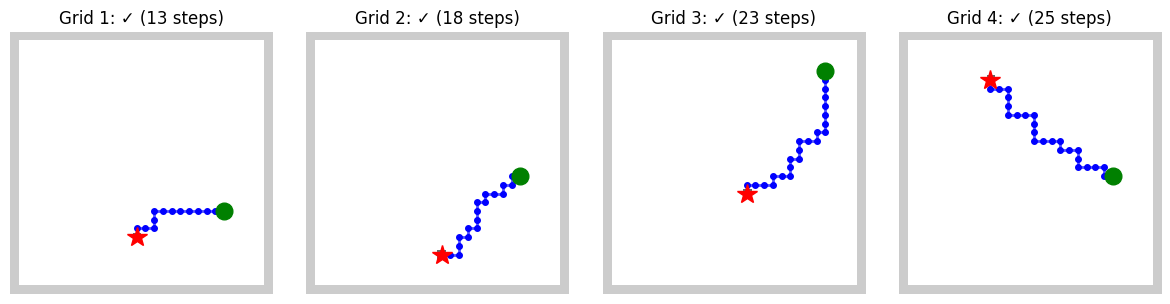


Results: 4/4 successful (100%)


In [26]:
# =============================================================================
# CELL: Test on 3 Unseen Grids
# =============================================================================

# Create 3 new grids not seen during training
test_grids = [
    make_grid((randint(1, 28), randint(1, 28)), start_pos=((randint(1, 28), randint(1, 28)))),   
    make_grid((randint(1, 28), randint(1, 28)), start_pos=((randint(1, 28), randint(1, 28)))),   
    make_grid((randint(1, 28), randint(1, 28)), start_pos=((randint(1, 28), randint(1, 28)))),  
    make_grid((randint(1, 28), randint(1, 28)), start_pos=((randint(1, 28), randint(1, 28))))
]

print("Testing on 3 unseen grids:\n")
visualize_all_grids(net, test_grids, max_steps=30)

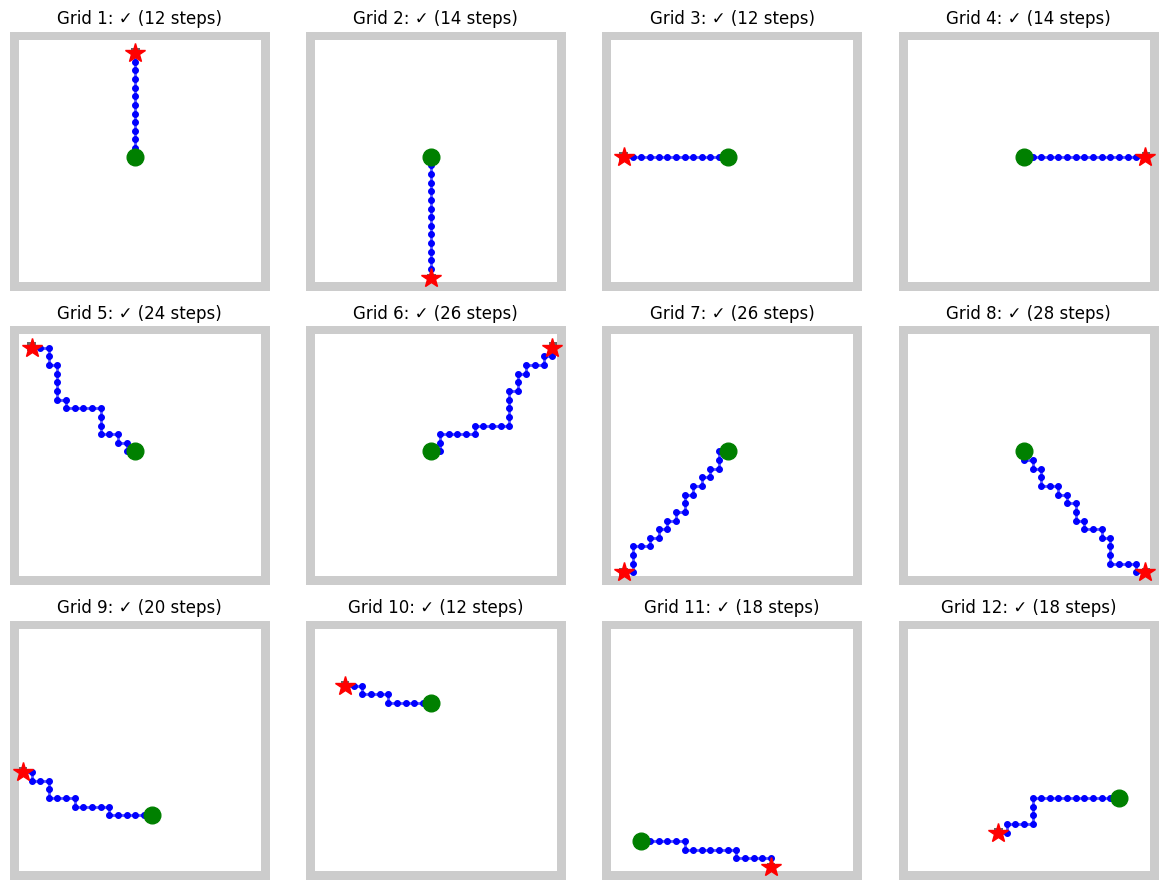


Results: 12/12 successful (100%)


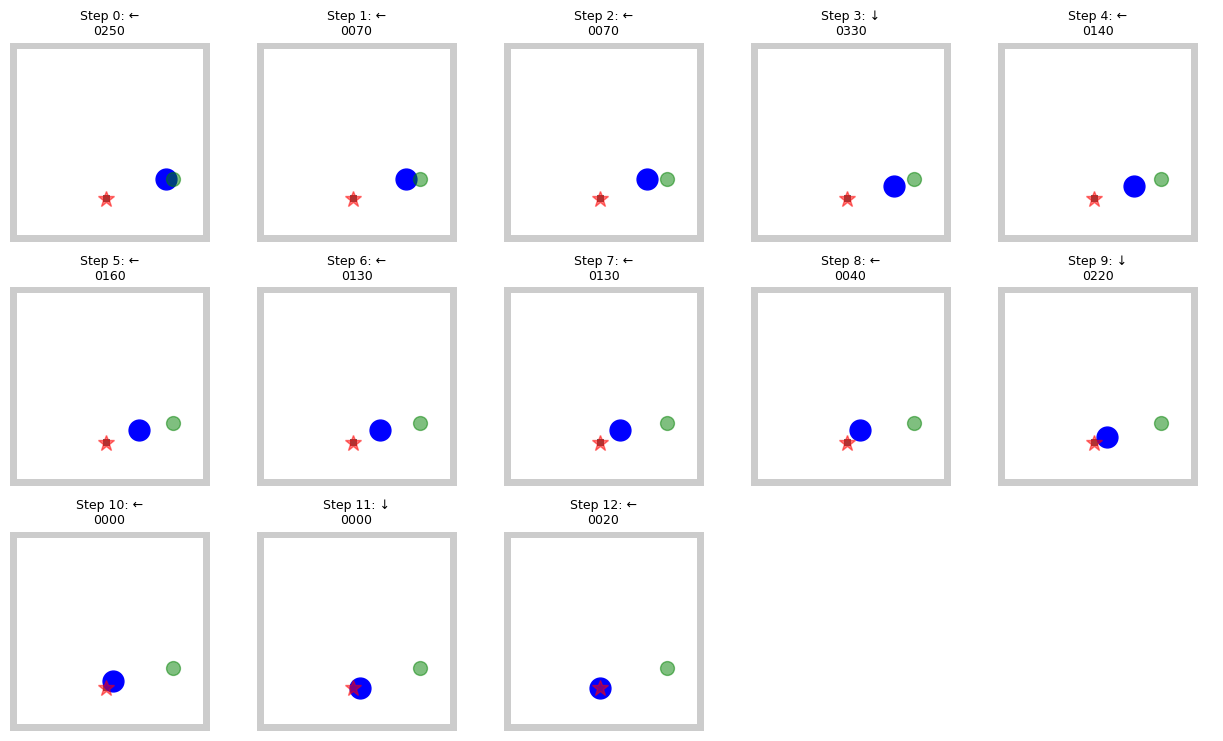

In [27]:
# Test all grids
visualize_all_grids(net, grids)

# Step by step breakdown
visualize_step_by_step(net, test_grids[0], max_steps=50)

# Animated (in Jupyter)
animate_run(net, test_grids[0], interval=400)